# Calcutta Auction + Advanced Metrics EDA

Combines Calcutta auction data with KenPom, EvanMiya, and 538 advanced metrics
to explore whether team quality metrics predict auction value and ROI.

In [3]:
%run build_calcutta_master.py

Rows: 128
Seasons: [2024, 2025]
Stage join rate: 100.0%

Sample row:
season                               2024
team_id                              1314
team_name                  North Carolina
seed                                    1
seed_region                             X
region                               West
conference                            acc
winning_bid                         13500
owner_name          Kent, Kenny + Company
reached_r64                             1
reached_r32                             1
reached_s16                             1
reached_e8                              0
reached_f4                              0
reached_f2                              0
won_championship                        0
furthest_round                          2
payout_pct                          0.015
payout_dollars                     6591.0
roi                               -0.5118

Saved to /Users/harrywang/Desktop/Data Projects/march-madness-calcutta/data/calcutta_maste

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Load Calcutta master
df = pd.read_csv("../../data/calcutta_master.csv")

# ── Name normalization for joining Calcutta ↔ Kaggle-metrics ──
# The two datasets use different ID systems, so we join on team name + year.
# Calcutta uses Kaggle MTeams names; kaggle-metrics use KenPom/Barttorvik names.

# Mapping: calcutta team_name (lowered) → kaggle-metrics TEAM (lowered)
NAME_MAP = {
    "alabama st": "alabama st.",
    "american univ": "american",
    "col charleston": "college of charleston",
    "colorado st": "colorado st.",
    "fl atlantic": "florida atlantic",
    "grambling": "grambling st.",
    "iowa st": "iowa st.",
    "long beach st": "long beach st.",
    "mcneese st": "mcneese st.",
    "michigan st": "michigan st.",
    "mississippi st": "mississippi st.",
    "morehead st": "morehead st.",
    "mt st mary's": "mount st. mary's",
    "nc state": "north carolina st.",
    "ne omaha": "nebraska omaha",
    "norfolk st": "norfolk st.",
    "s dakota st": "south dakota st.",
    "san diego st": "san diego st.",
    "siue": "siu edwardsville",
    "st john's": "st. john's",
    "st mary's ca": "saint mary's",
    "st peter's": "saint peter's",
    "utah st": "utah st.",
    "washington st": "washington st.",
    "wku": "western kentucky",
}

def normalize_name(name):
    """Lowercase, strip, then apply manual mapping."""
    n = name.strip().lower()
    return NAME_MAP.get(n, n)

df["join_name"] = df["team_name"].apply(normalize_name)

# Load KenPom Barttorvik metrics
kp = pd.read_csv("../../data/kaggle-metrics/KenPom Barttorvik.csv",
                  usecols=["YEAR", "TEAM", "KADJ EM", "KADJ O", "KADJ D"])
kp["join_name"] = kp["TEAM"].apply(normalize_name)

# Load EvanMiya metrics
em = pd.read_csv("../../data/kaggle-metrics/EvanMiya.csv",
                  usecols=["YEAR", "TEAM", "RELATIVE RATING"])
em["join_name"] = em["TEAM"].apply(normalize_name)

# Load 538 Ratings (2024 only)
fiv = pd.read_csv("../../data/kaggle-metrics/538 Ratings.csv",
                   usecols=["YEAR", "TEAM", "POWER RATING"])
fiv["join_name"] = fiv["TEAM"].apply(normalize_name)

# Join metrics onto Calcutta master using (season↔YEAR, join_name)
df = df.merge(kp[["YEAR", "join_name", "KADJ EM", "KADJ O", "KADJ D"]],
              left_on=["season", "join_name"], right_on=["YEAR", "join_name"], how="left")
df.drop(columns=["YEAR"], inplace=True)

df = df.merge(em[["YEAR", "join_name", "RELATIVE RATING"]],
              left_on=["season", "join_name"], right_on=["YEAR", "join_name"], how="left")
df.drop(columns=["YEAR"], inplace=True)

df = df.merge(fiv[["YEAR", "join_name", "POWER RATING"]],
              left_on=["season", "join_name"], right_on=["YEAR", "join_name"], how="left")
df.drop(columns=["YEAR"], inplace=True)

print(f"Rows: {len(df)}")
print(f"KADJ EM non-null: {df['KADJ EM'].notna().sum()} / {len(df)}")
print(f"RELATIVE RATING non-null: {df['RELATIVE RATING'].notna().sum()} / {len(df)}")
print(f"POWER RATING non-null: {df['POWER RATING'].notna().sum()} / {len(df)}")
df.head()

Rows: 128
KADJ EM non-null: 128 / 128
RELATIVE RATING non-null: 128 / 128
POWER RATING non-null: 64 / 128


,season,team_id,team_name,seed,seed_region,region,conference,winning_bid,owner_name,reached_r64,...,furthest_round,payout_pct,payout_dollars,roi,join_name,KADJ EM,KADJ O,KADJ D,RELATIVE RATING,POWER RATING
0,2024,1314,North Carolina,1,X,West,acc,13500,"Kent, Kenny + Company",1,...,2,0.0150,6591.0,-0.5118,north carolina,24.6454,117.796,93.1510,24.134042,90.2
1,2024,1345,Purdue,1,Y,Midwest,big_ten,20000,Bisaillon + Hilding + Dudash + Nardi + Carr,1,...,5,0.1075,47235.5,1.3618,purdue,29.1183,124.988,95.8700,28.473287,93.5
2,2024,1222,Houston,1,Z,South,big_twelve,22000,Moncrief + Sparty,1,...,2,0.0150,6591.0,-0.7004,houston,31.7188,118.868,87.1492,25.633417,94.9
3,2024,1163,Connecticut,1,W,East,big_east,31000,"Kent, Kenny + Company",1,...,6,0.1775,77993.5,1.5159,connecticut,32.2130,126.608,94.3949,32.873291,95.6
4,2024,1112,Arizona,2,X,West,pac_twelve,13800,McManama,1,...,2,0.0150,6591.0,-0.5224,arizona,26.6237,121.125,94.5013,25.276858,91.6


### KenPom Rating vs Winning Bid
Does the auction track the best predictive metric?

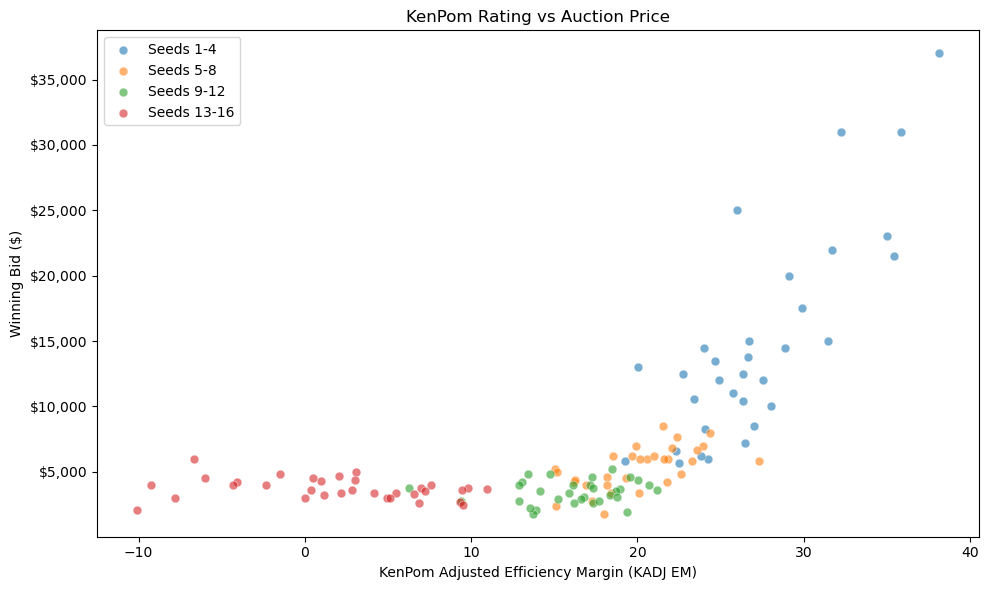

In [5]:
plot_df = df.dropna(subset=["KADJ EM"]).copy()

# Seed tiers for coloring
def seed_tier(s):
    if s <= 4:
        return "1-4"
    elif s <= 8:
        return "5-8"
    elif s <= 12:
        return "9-12"
    else:
        return "13-16"

plot_df["seed_tier"] = plot_df["seed"].apply(seed_tier)
tier_colors = {"1-4": "#1f77b4", "5-8": "#ff7f0e", "9-12": "#2ca02c", "13-16": "#d62728"}

fig, ax = plt.subplots(figsize=(10, 6))
for tier, color in tier_colors.items():
    mask = plot_df["seed_tier"] == tier
    ax.scatter(plot_df.loc[mask, "KADJ EM"], plot_df.loc[mask, "winning_bid"],
               alpha=0.6, s=40, c=color, label=f"Seeds {tier}", edgecolors="white", linewidth=0.5)
ax.set_xlabel("KenPom Adjusted Efficiency Margin (KADJ EM)")
ax.set_ylabel("Winning Bid ($)")
ax.set_title("KenPom Rating vs Auction Price")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

### KenPom Rating vs ROI
Are high-rated teams overpriced or still good value?

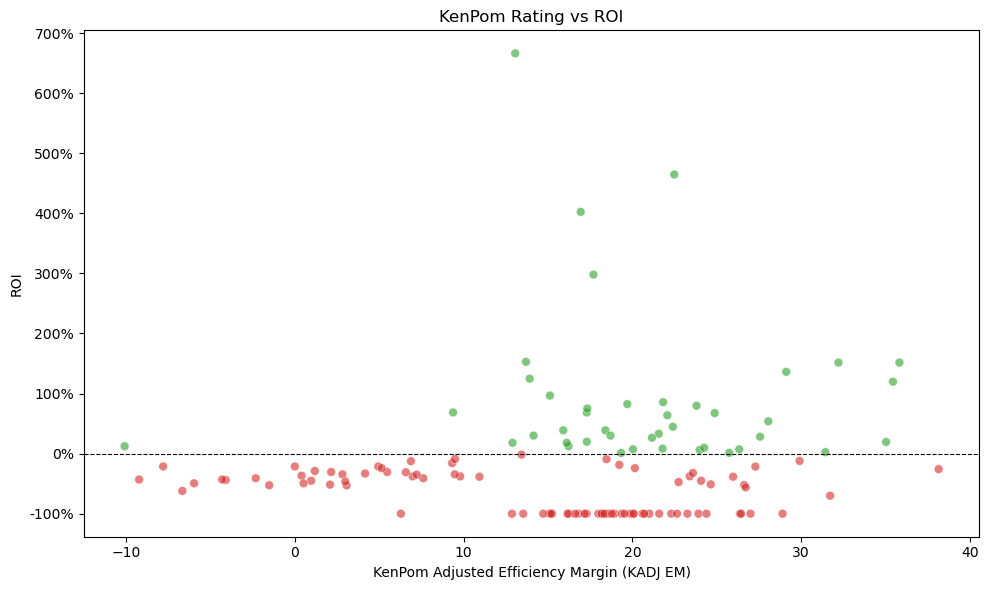

In [6]:
plot_df = df.dropna(subset=["KADJ EM"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ca02c" if r >= 0 else "#d62728" for r in plot_df["roi"]]
ax.scatter(plot_df["KADJ EM"], plot_df["roi"], alpha=0.6, s=40, c=colors, edgecolors="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("KenPom Adjusted Efficiency Margin (KADJ EM)")
ax.set_ylabel("ROI")
ax.set_title("KenPom Rating vs ROI")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

### Bid Premium Over Expected by Seed
For each seed, compare actual mean bid to mean KenPom rating within that seed.
Highlights seeds where the auction overpays relative to team quality.

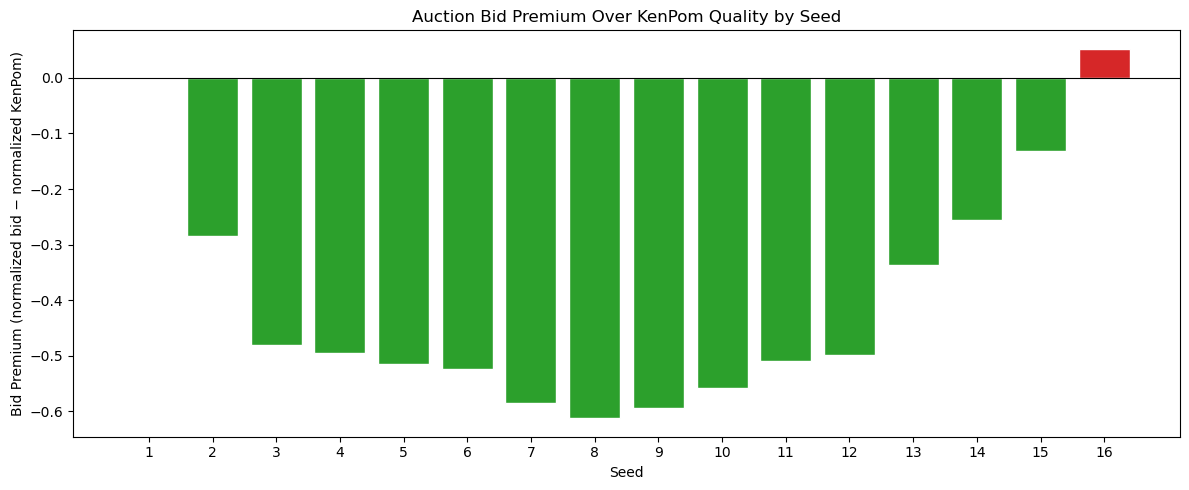

In [7]:
seed_stats = df.dropna(subset=["KADJ EM"]).groupby("seed").agg(
    mean_bid=("winning_bid", "mean"),
    mean_kadj=("KADJ EM", "mean"),
).reset_index()

# Normalize both to 0-1 scale for comparison
seed_stats["bid_norm"] = (seed_stats["mean_bid"] - seed_stats["mean_bid"].min()) / \
                          (seed_stats["mean_bid"].max() - seed_stats["mean_bid"].min())
seed_stats["kadj_norm"] = (seed_stats["mean_kadj"] - seed_stats["mean_kadj"].min()) / \
                           (seed_stats["mean_kadj"].max() - seed_stats["mean_kadj"].min())
seed_stats["premium"] = seed_stats["bid_norm"] - seed_stats["kadj_norm"]

colors = ["#d62728" if v > 0 else "#2ca02c" for v in seed_stats["premium"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(seed_stats["seed"], seed_stats["premium"], color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Bid Premium (normalized bid − normalized KenPom)")
ax.set_title("Auction Bid Premium Over KenPom Quality by Seed")
ax.set_xticks(seed_stats["seed"])
plt.tight_layout()
plt.show()

### EvanMiya Rating vs Tournament Round Reached
Does the rating predict how far teams advance?

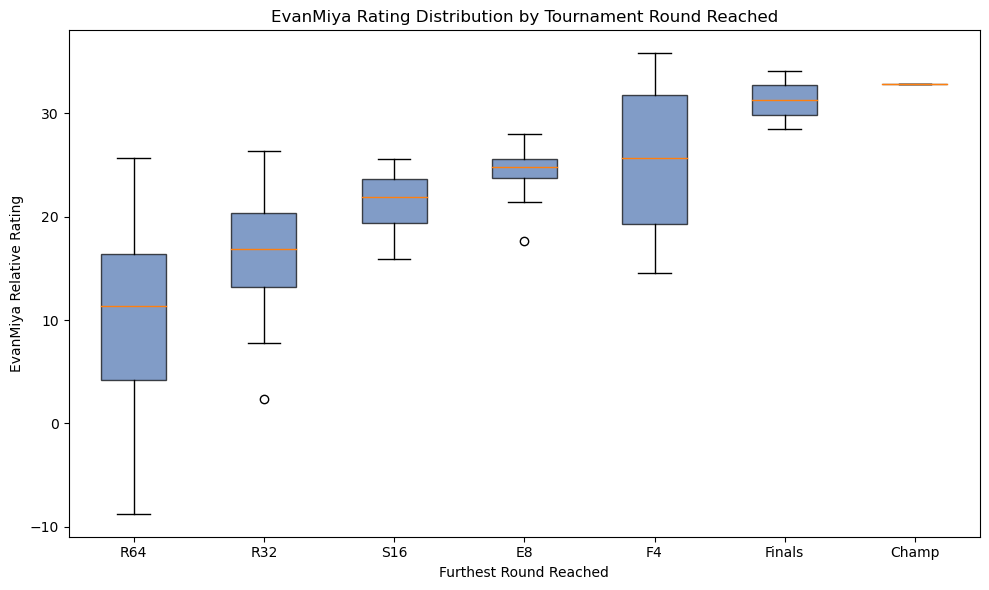

In [8]:
round_labels = {0: "R64", 1: "R32", 2: "S16", 3: "E8", 4: "F4", 5: "Finals", 6: "Champ"}
plot_df = df.dropna(subset=["RELATIVE RATING"]).copy()
plot_df["round_label"] = plot_df["furthest_round"].map(round_labels)

# Order rounds for the box plot
round_order = ["R64", "R32", "S16", "E8", "F4", "Finals", "Champ"]
present_rounds = [r for r in round_order if r in plot_df["round_label"].values]

fig, ax = plt.subplots(figsize=(10, 6))
data = [plot_df[plot_df["round_label"] == r]["RELATIVE RATING"].values for r in present_rounds]
bp = ax.boxplot(data, labels=present_rounds, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)
ax.set_xlabel("Furthest Round Reached")
ax.set_ylabel("EvanMiya Relative Rating")
ax.set_title("EvanMiya Rating Distribution by Tournament Round Reached")
plt.tight_layout()
plt.show()

### Metric Correlation Heatmap
Correlation between auction, tournament, and advanced metric variables.

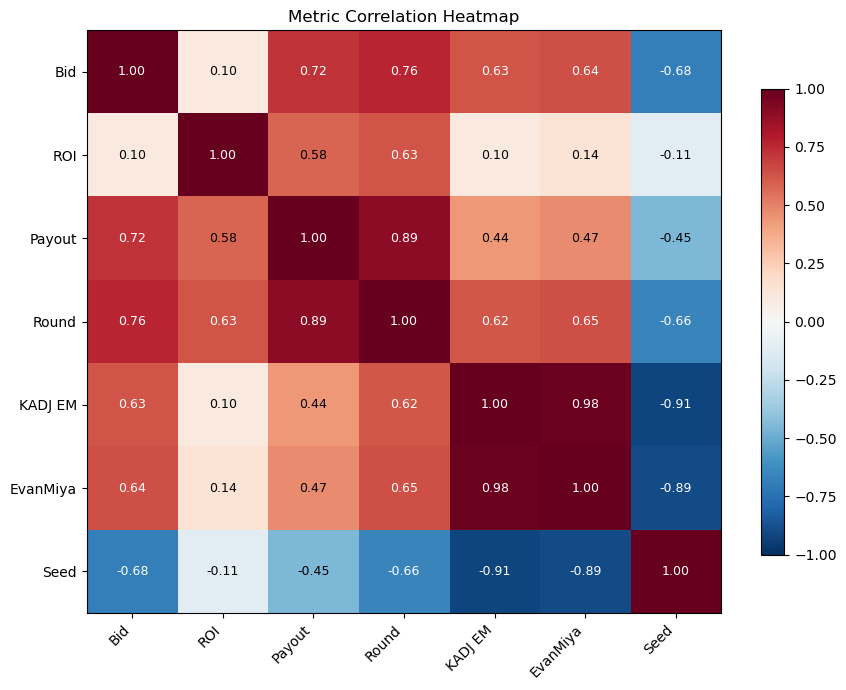

In [9]:
corr_cols = ["winning_bid", "roi", "payout_dollars", "furthest_round",
             "KADJ EM", "RELATIVE RATING", "seed"]
corr_df = df[corr_cols].dropna()

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
labels = ["Bid", "ROI", "Payout", "Round", "KADJ EM", "EvanMiya", "Seed"]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix.values[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Metric Correlation Heatmap")
plt.tight_layout()
plt.show()

### Biggest Auction Mispricings
Top 10 teams by absolute difference between KenPom rank and bid rank (within same year).
Identifies most over/under-valued teams.

In [ ]:
mis = df.dropna(subset=["KADJ EM"]).copy()

# Rank within each year: higher KADJ EM = rank 1, higher bid = rank 1
mis["kadj_rank"] = mis.groupby("season")["KADJ EM"].rank(ascending=False).astype(int)
mis["bid_rank"] = mis.groupby("season")["winning_bid"].rank(ascending=False).astype(int)
mis["rank_diff"] = mis["bid_rank"] - mis["kadj_rank"]  # positive = overpaid
mis["abs_rank_diff"] = mis["rank_diff"].abs()

top_mis = mis.nlargest(10, "abs_rank_diff")

display_cols = ["season", "team_name", "seed", "winning_bid", "KADJ EM",
                "bid_rank", "kadj_rank", "rank_diff", "roi"]
result = top_mis[display_cols].copy()
result["mispricing"] = result["rank_diff"].apply(
    lambda x: "UNDERPAID" if x > 0 else "OVERPAID")
result = result.reset_index(drop=True)
result.index += 1
result

,season,team_name,seed,winning_bid,KADJ EM,bid_rank,kadj_rank,rank_diff,roi,mispricing
1,2025,Mt St Mary's,16,6000,-6.67224,23,63,-40,-0.6207,UNDERPAID
2,2024,Mississippi St,8,1800,17.98250,64,29,35,-1.0000,OVERPAID
3,2025,Norfolk St,16,4800,-1.52118,29,60,-31,-0.5259,UNDERPAID
4,2024,WKU,15,5000,3.06263,25,55,-30,-0.5281,UNDERPAID
5,2025,Georgia,9,1900,19.36410,63,33,30,-1.0000,OVERPAID
6,2024,Dayton,7,2800,17.29750,59,30,29,0.6856,OVERPAID
7,2025,American Univ,16,4500,-5.97620,34,62,-28,-0.4943,UNDERPAID
8,2024,Stetson,16,4200,-4.10410,35,62,-27,-0.4382,UNDERPAID
9,2024,Longwood,16,4300,0.95941,33,59,-26,-0.4513,UNDERPAID
10,2025,Alabama St,16,4000,-9.23500,38,64,-26,-0.4311,UNDERPAID
